In [40]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

from unifigs.figures import RatioPlot
from NNMFit.utilities import load_pickle


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Bestfit Histograms (from step0_2_1_reco_space_graphs.ipynb)

In [ ]:
step0_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/graphs"

# Each entry defines one figure.
# 'scans' is a list of (scan_name, label) pairs — 1 for a single dataset, 2+ to overlay.
PLOTS = [
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Cascades — With Systematics",
        "scans": [
            ("hese_spectrum_bestfit_13year_round3", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Cascades — No Systematics",
        "scans": [
            ("hese_spectrum_bestfit_13year_round3_NoSystematics", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Tracks — With Systematics",
        "scans": [
            ("hese_spectrum_bestfit_13year_round3", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Tracks — No Systematics",
        "scans": [
            ("hese_spectrum_bestfit_13year_round3_NoSystematics", "MC"),
        ],
    },

    # combined plots
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined — No Systematics",
        "scans": [
            ("hese_combined_spectrum_bestfit_13year_round3_NoSystematics", "MC"),
        ],
    },

    # spice
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Spice Cascades — No Systematics",
        "scans": [
            ("hese_seed_neha_NoSystematics", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Spice Tracks — No Systematics",
        "scans": [
            ("hese_seed_neha_NoSystematics", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades",
        "title": "HESE Spice Doubles — No Systematics",
        "scans": [
            ("hese_seed_neha_NoSystematics", "MC"),
        ],
    },

    # ftp sim and data
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Cascades — Best fit Neha, with flavor",
        "scans": [
            ("FTP_data_sim_seed_neha_WithFlavor_NoSystematics", "MC"),
        ],
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Tracks — Best fit Neha, with flavor",
        "scans": [
            ("FTP_data_sim_seed_neha_WithFlavor_NoSystematics", "MC"),
        ],
    },

]

In [48]:
# collect unique scan names in order they first appear
scan_names = list(dict.fromkeys(
    scan_name
    for plot in PLOTS
    for scan_name, _ in plot["scans"]
))

histogram_collection = {}
for scan_name in scan_names:
    print(scan_name)
    histogram_collection[scan_name] = {}
    data_hist_path = glob.glob(os.path.join(step0_path, scan_name, "Data_Histogram.pickle"))
    if len(data_hist_path) != 1:
        raise ValueError(f"Expected exactly one Data_Histogram.pickle for {scan_name}, found {len(data_hist_path)}")
    histogram_collection[scan_name]["data"] = load_pickle(data_hist_path[0])

    mc_hist_path = glob.glob(os.path.join(step0_path, scan_name, "MC_Histogram*.pickle"))
    if len(mc_hist_path) < 1:
        raise ValueError(f"Expected at least one MC_Histogram.pickle for {scan_name}, found {len(mc_hist_path)}")
    histogram_collection[scan_name]["mc"] = load_pickle(mc_hist_path[0])

hese_spectrum_bestfit_13year_round3
hese_spectrum_bestfit_13year_round3_NoSystematics
hese_combined_spectrum_bestfit_13year_round3_NoSystematics
hese_seed_neha_NoSystematics
FTP_data_sim_seed_neha_WithFlavor_NoSystematics


### Meta Information for binning and plotting

In [49]:
dimensions = {
    "IC86_pass2_SnowStorm_FTP_HESE_Cascades": {
        "reco_energy": {
            "binning_key": "reco_energy",
            "log_x": True,
            "log_y": True,
            "x_label": r"$E_{\mathrm{reco}}$ [GeV]",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 1,
            "flip": False,
            "ylims": [1e-11, 3e-4],
        },
        "reco_zenith": {
            "binning_key": "reco_zenith",
            "log_x": False,
            "log_y": False,
            "x_label": r"$\cos(\theta_{\mathrm{reco}})$",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 0,
            "flip": True,
            "ylims": None,
        },
    },
    "IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades": {
        "reco_energy": {
            "binning_key": "reco_energy",
            "log_x": True,
            "log_y": True,
            "x_label": r"$E_{\mathrm{reco}}$ [GeV]",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 1,
            "flip": False,
            "ylims": [1e-11, 3e-4],
        },
        "reco_length": {
            "binning_key": "reco_length",
            "log_x": True,
            "log_y": True,
            "x_label": r"$L_{\tau}$ [m]",
            "y_label": "Expected Rate [Hz]",
            "sum_axes": 0,
            "flip": False,
            "ylims": None,
        },
    },
}

dimensions["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]   = dimensions["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]
dimensions["IC86_pass2_SnowStorm_FTP_HESE_Combined"] = dimensions["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]


In [44]:
binning_dict = {}

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 24)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]["reco_zenith"] = np.linspace(-1, 1, 11)

binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Tracks"]   = binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Combined"] = binning_dict["IC86_pass2_SnowStorm_FTP_HESE_Cascades"]

# DoubleCascades: reco_energy_binning = (4.778, 7.1, 14, log) → 14 edges, 13 bins
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"] = {}
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["reco_energy"] = np.geomspace(10**4.778, 10**7.1, 14)
binning_dict["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]["reco_length"] = np.geomspace(1e1, 1e3, 11)


### Plotting Functions

In [45]:
def get_histogram_projection(
    histogram, det_config, binning_dict, projected_dimension, flip=False
):
    reshape_shape = tuple(
        binning_dict[det_config][dim].shape[0] - 1
        for dim in binning_dict[det_config]
    )
    sum_axis = dimensions[det_config][projected_dimension]["sum_axes"]
    h = np.sum(np.reshape(histogram, reshape_shape), axis=sum_axis)
    if flip:
        h = np.flip(h, axis=0)
    return h


def plot_histogram(
    ax, histogram_dict, det_config, plot_dimension, fit_dimension, binning_dict,
    draw_style="stairs", label="Label", color="black", **kwargs,
):
    histogram = get_histogram_projection(
        histogram_dict["histograms"][det_config], det_config, binning_dict,
        projected_dimension=plot_dimension,
        flip=dimensions[det_config][plot_dimension]["flip"],
    )
    if "fluctuations" not in histogram_dict or histogram_dict["fluctuations"] is None:
        fluctuations = np.sqrt(histogram)
    else:
        fluctuations = get_histogram_projection(
            np.sqrt(histogram_dict["fluctuations"][det_config]), det_config, binning_dict,
            projected_dimension=plot_dimension,
            flip=dimensions[det_config][plot_dimension]["flip"],
        )
    if draw_style == "stairs":
        ax.stairs(histogram, binning_dict[det_config][plot_dimension],
                  label=label, color=color, **kwargs)
    elif draw_style == "errors":
        bin_centers = (
            np.diff(binning_dict[det_config][plot_dimension]) / 2
            + binning_dict[det_config][plot_dimension][:-1]
        )
        ax.errorbar(bin_centers, histogram, yerr=fluctuations,
                    fmt=".", label=label, color=color, **kwargs)


def calc_ratio_err(numerator, denominator, err_numerator, err_denominator):
    ratio = numerator / denominator
    ratio_err = ratio * np.sqrt(
        (err_numerator / numerator)**2 + (err_denominator / denominator)**2
    )
    return ratio, ratio_err


def plot_ratio(
    ax, mc_dict, data_dict, det_config, plot_dimension, binning_dict,
    include_mc_err=True, label="Ratio", color="black", capsize=2,
    markeredgecolor="black", **kwargs,
):
    reshape_shape = tuple(
        binning_dict[det_config][dim].shape[0] - 1
        for dim in binning_dict[det_config]
    )
    sum_axis = dimensions[det_config][plot_dimension]["sum_axes"]
    flip     = dimensions[det_config][plot_dimension]["flip"]

    mc_h   = np.sum(np.reshape(mc_dict["histograms"][det_config],   reshape_shape), axis=sum_axis)
    data_h = np.sum(np.reshape(data_dict["histograms"][det_config], reshape_shape), axis=sum_axis)
    if include_mc_err:
        mc_ssq = np.sum(np.reshape(mc_dict["fluctuations"][det_config], reshape_shape), axis=sum_axis)

    if flip:
        mc_h   = np.flip(mc_h)
        data_h = np.flip(data_h)
        if include_mc_err:
            mc_ssq = np.flip(mc_ssq)

    if include_mc_err:
        ratio, ratio_err = calc_ratio_err(
            data_h, mc_h, np.sqrt(data_h), np.sqrt(mc_ssq)
        )
    else:
        ratio, ratio_err = calc_ratio_err(
            data_h, mc_h, np.sqrt(data_h), np.zeros_like(mc_h)
        )

    bin_centers = (
        np.diff(binning_dict[det_config][plot_dimension]) / 2
        + binning_dict[det_config][plot_dimension][:-1]
    )
    ax.errorbar(
        bin_centers, ratio, yerr=ratio_err, fmt=".",
        label=label, color=color, elinewidth=1, capsize=capsize,
        markeredgecolor=markeredgecolor, **kwargs,
    )


def plot_data_points(axes, det_config, histogram_collection, scan_name,
                     binning_dict, color="black", label="Data"):
    for col, dim in enumerate(dimensions[det_config]):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["data"],
            det_config, dim, "2D", binning_dict,
            draw_style="errors", label=label, color=color,
        )


def plot_mc_and_ratio(axes, det_config, histogram_collection, scan_name,
                      binning_dict, color, hist_label="", ratio_label=""):
    for col, dim in enumerate(dimensions[det_config]):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["mc"],
            det_config, dim, "2D", binning_dict,
            draw_style="stairs", label=hist_label, color=color,
        )
        plot_ratio(
            axes[1][col], histogram_collection[scan_name]["mc"],
            histogram_collection[scan_name]["data"],
            det_config, dim, binning_dict,
            label=ratio_label, color=color,
        )


### Plots

In [55]:
%matplotlib inline
save_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/plots"
os.makedirs(save_path, exist_ok=True)


/tmp/ipykernel_1981799/3421116638.py:47: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


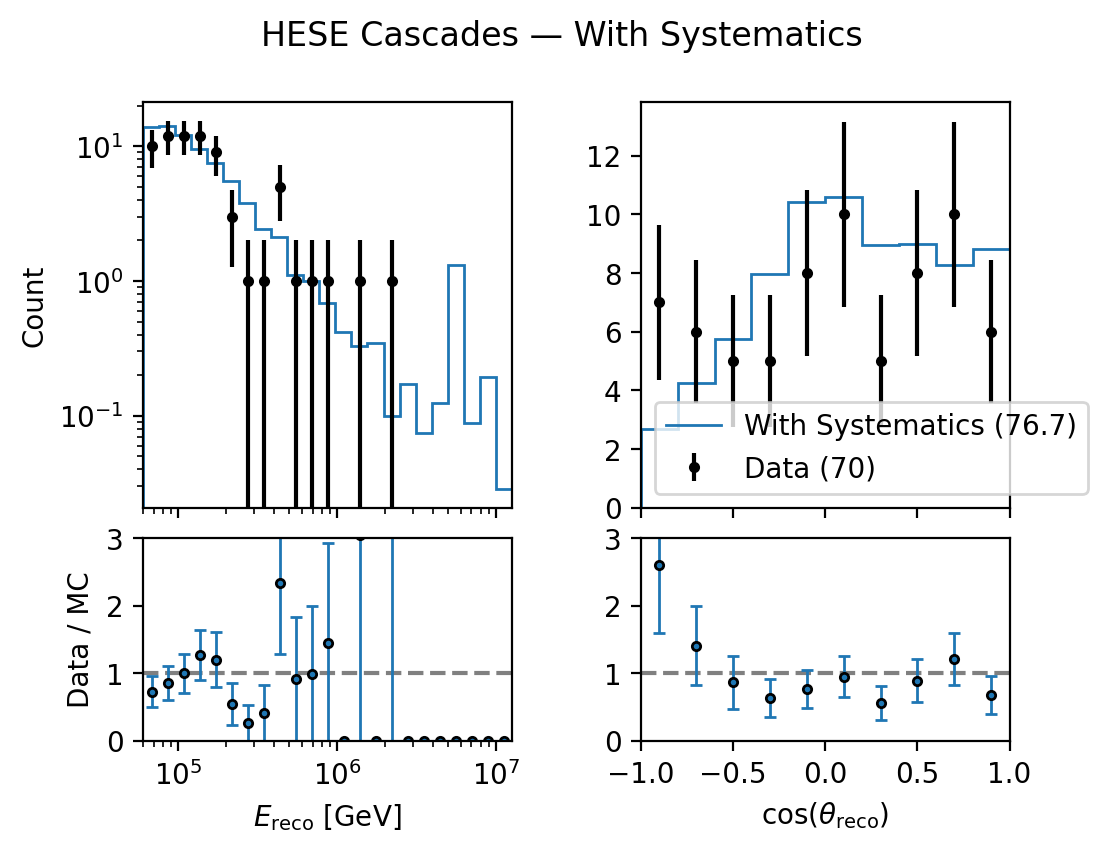

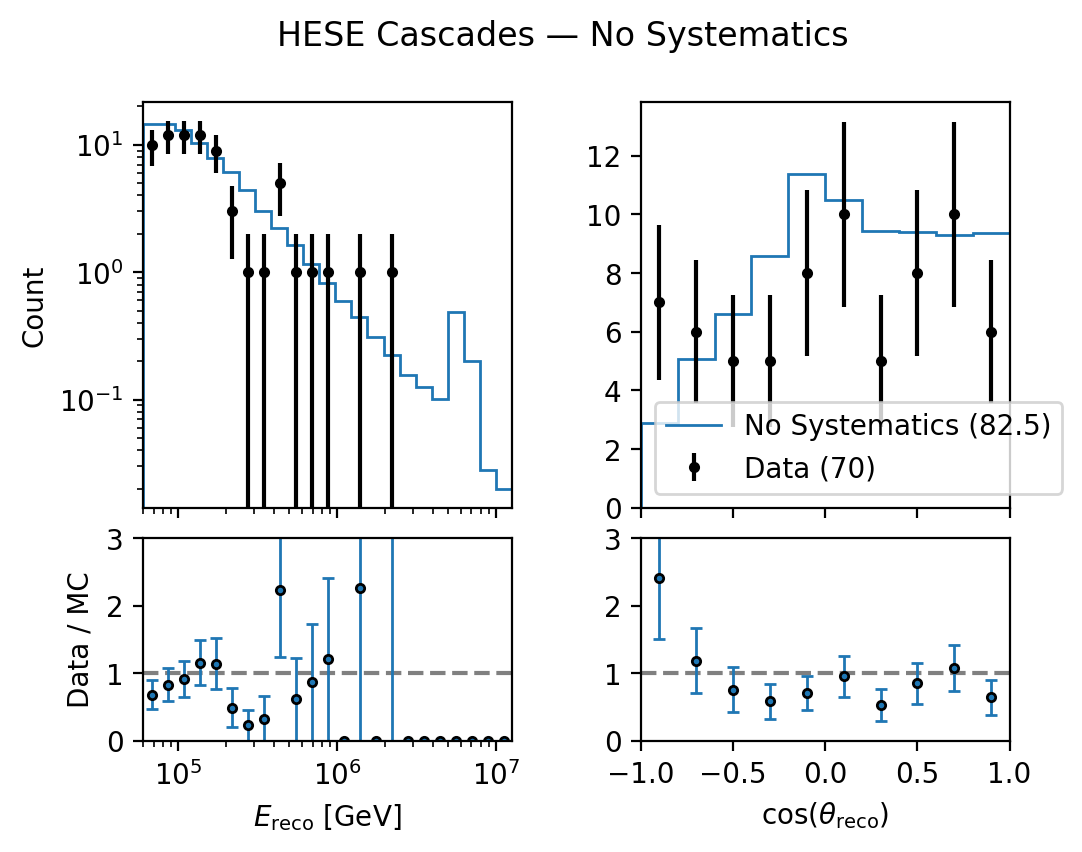

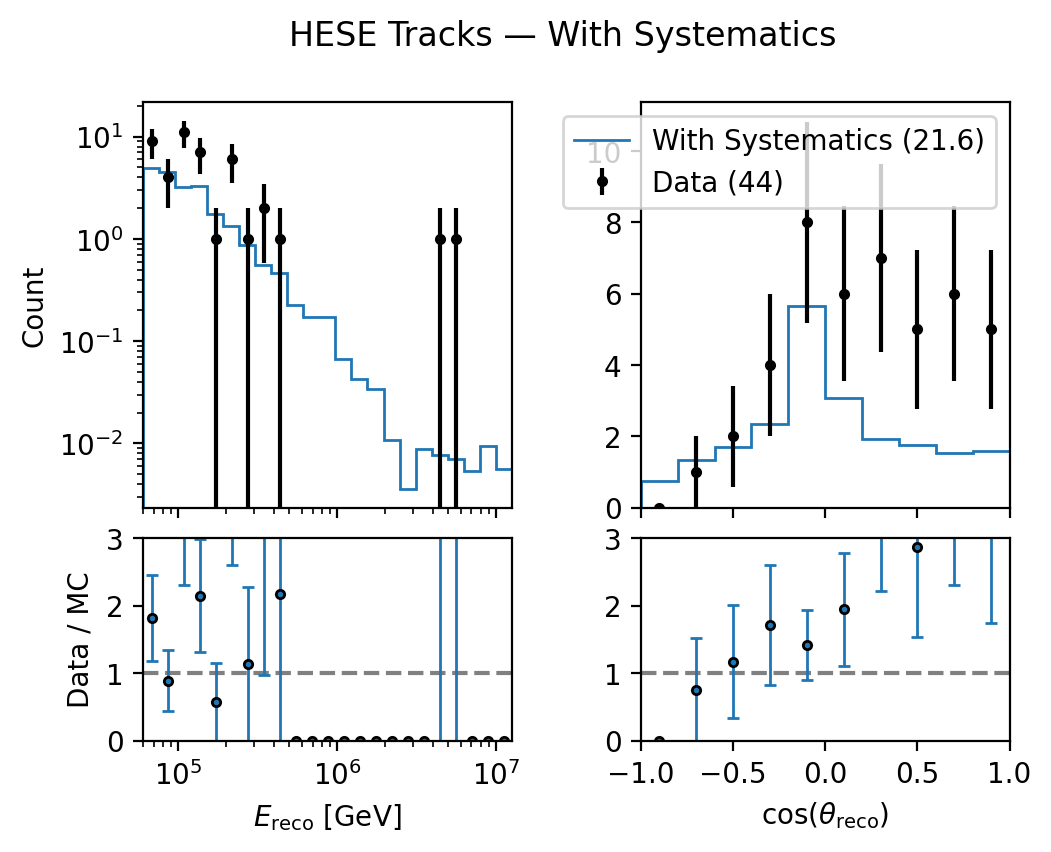

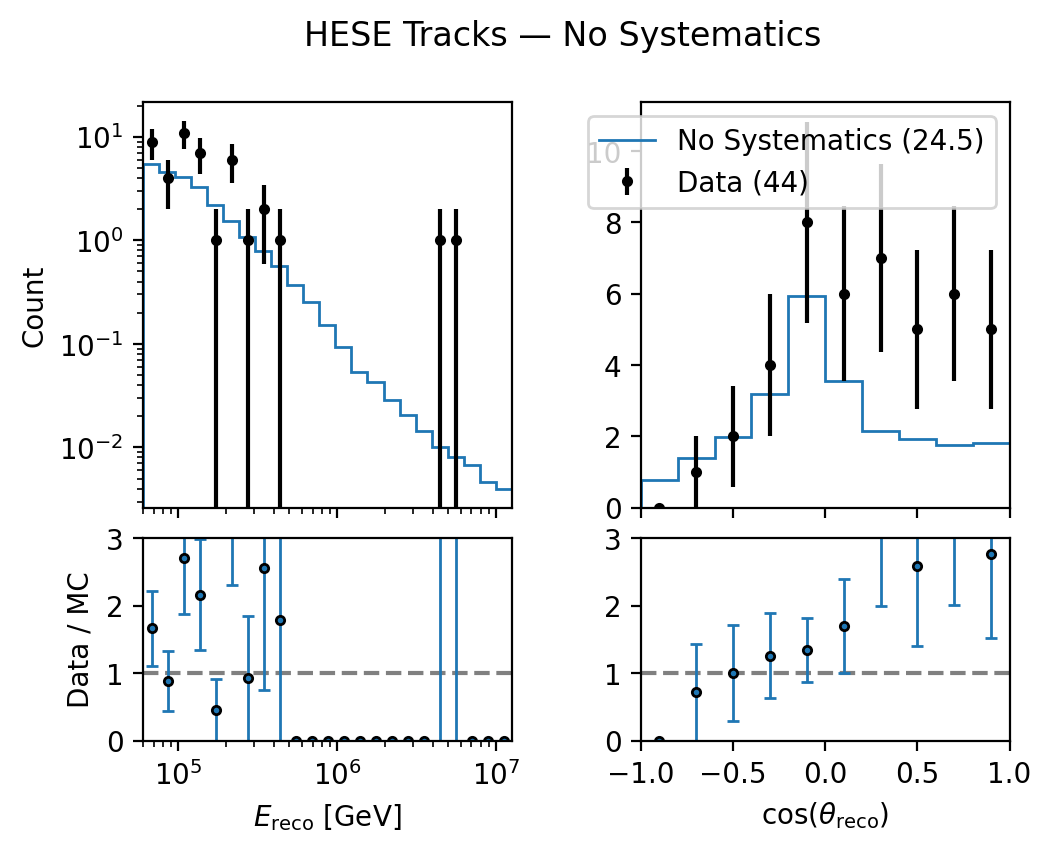

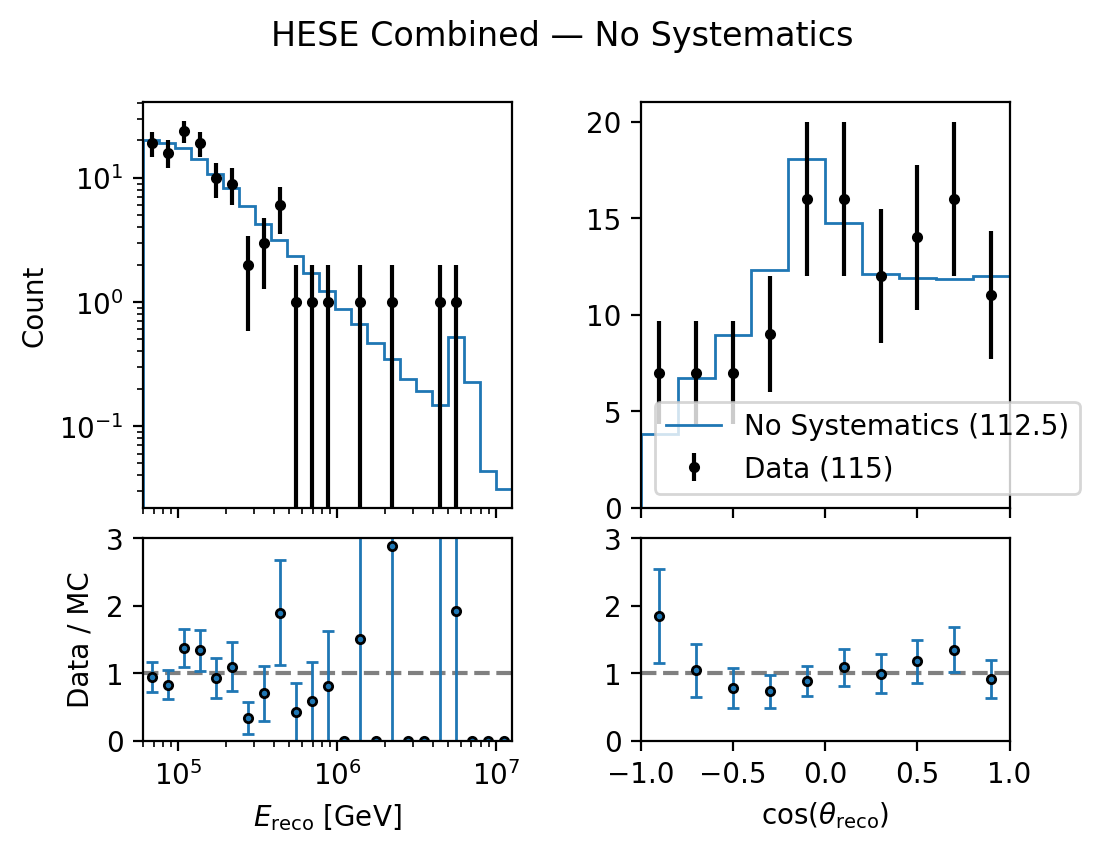

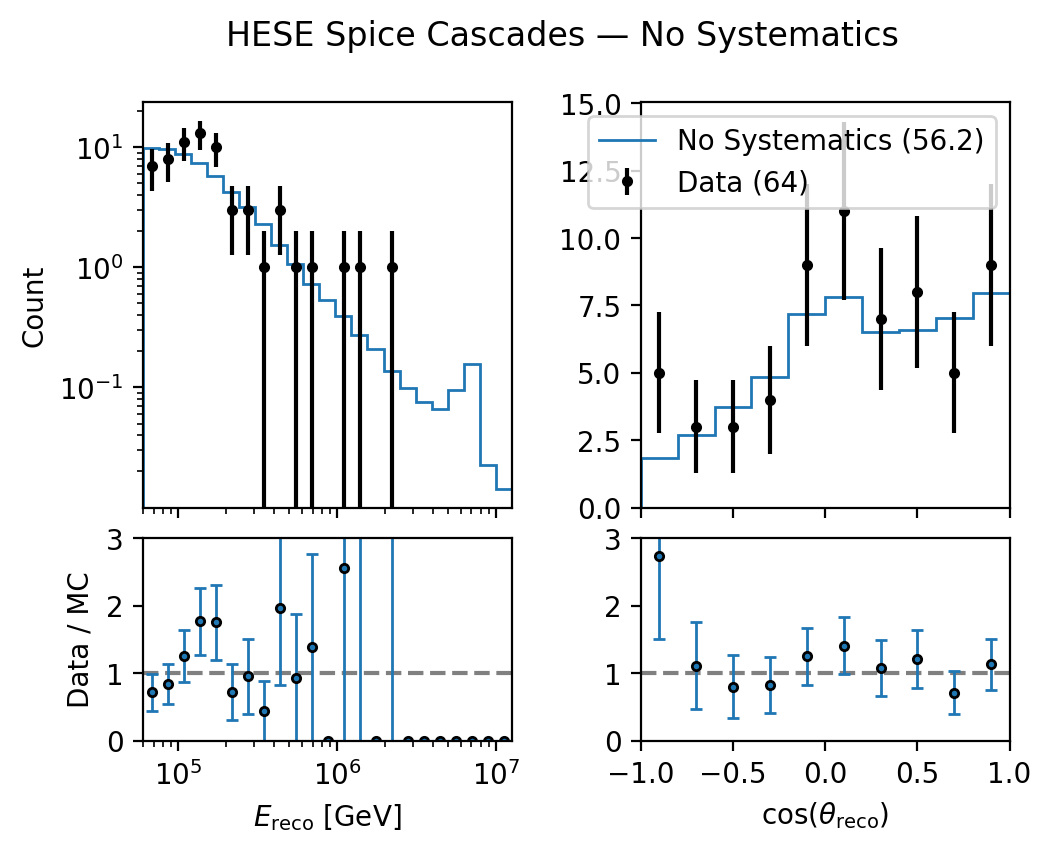

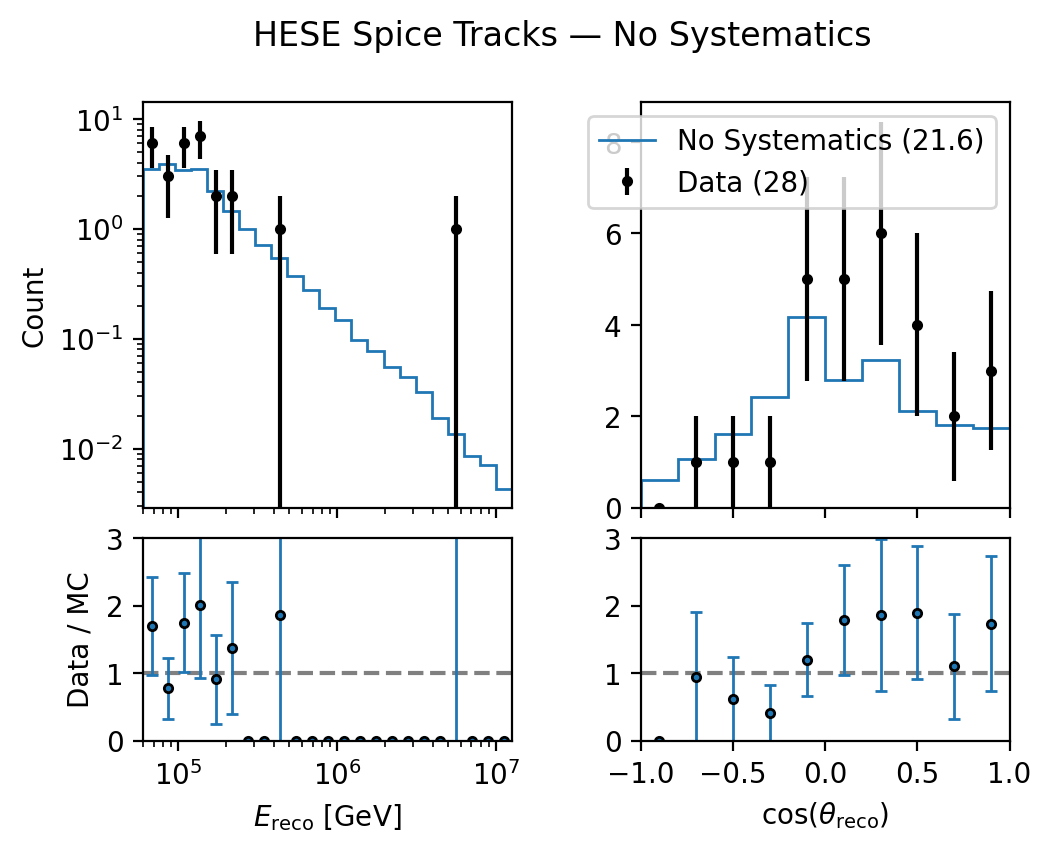

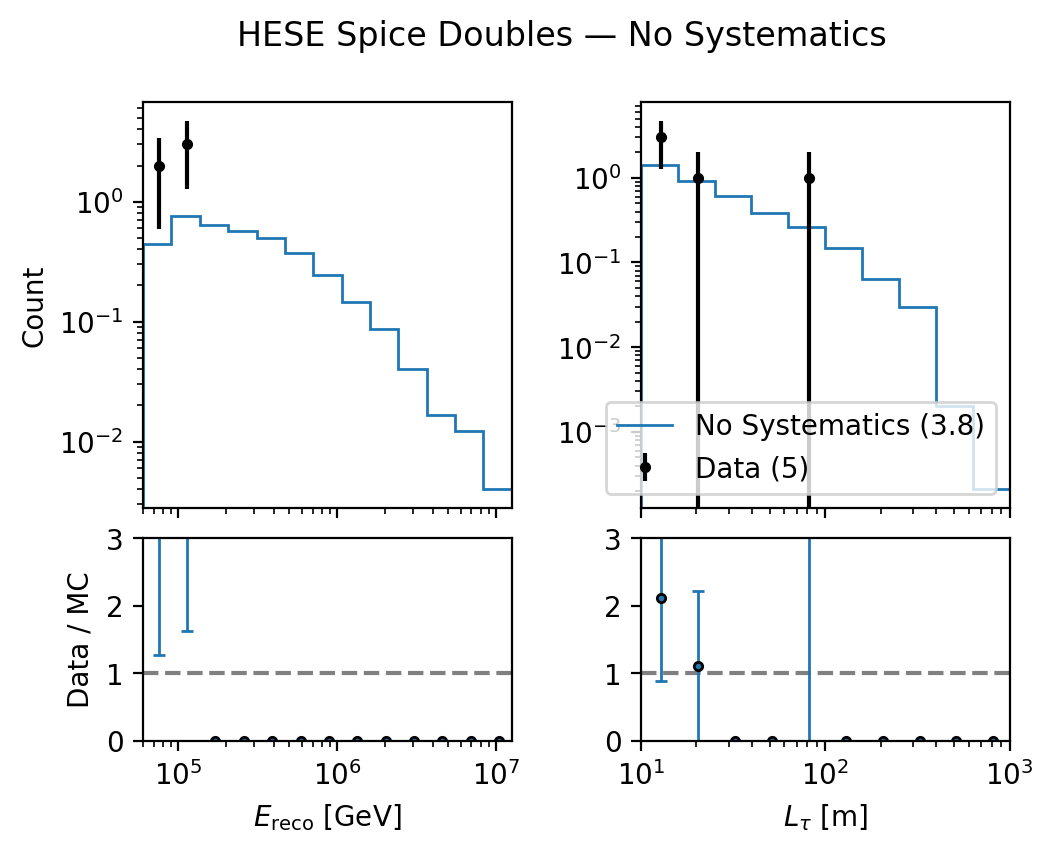

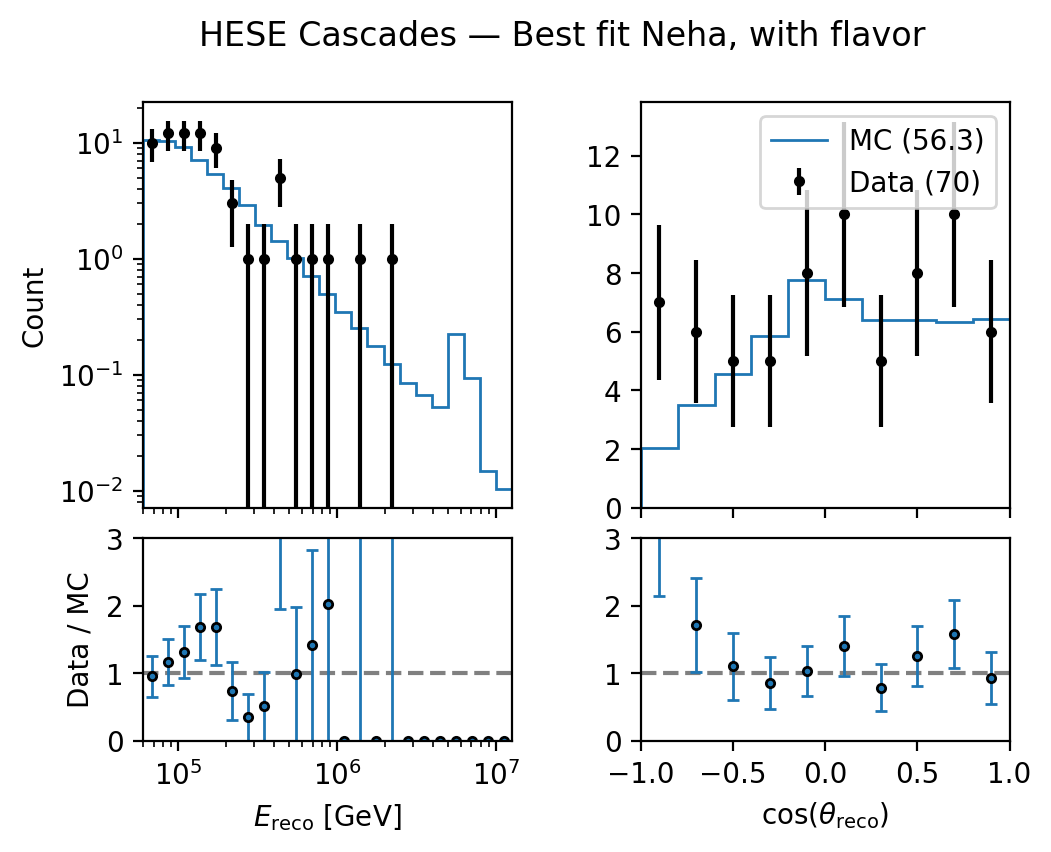

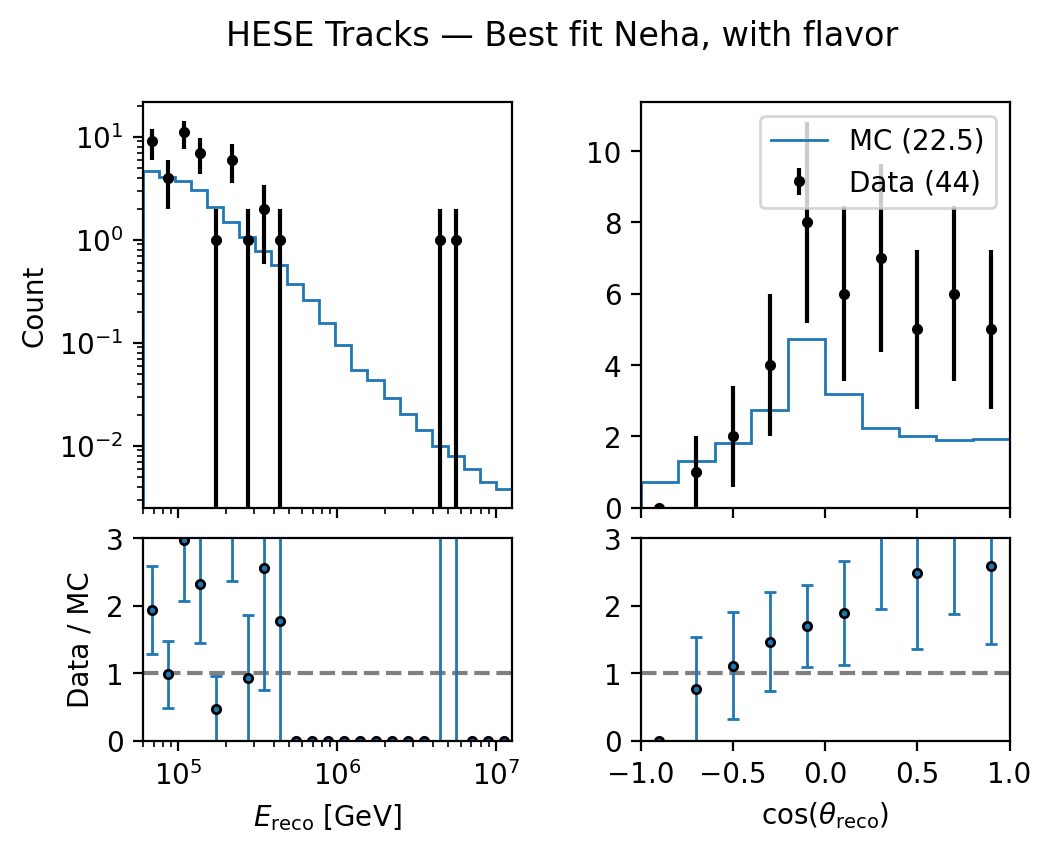

In [ ]:
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for plot in PLOTS:
    det_config = plot["det_config"]
    scans      = plot["scans"]
    dims       = list(dimensions[det_config].keys())

    fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)

    # data points from the first scan (real data is the same across scans)
    n_data = int(np.sum(histogram_collection[scans[0][0]]["data"]["histograms"][det_config]))
    plot_data_points(
        axes, det_config, histogram_collection, scans[0][0],
        binning_dict=binning_dict, color="black", label=f"Data ({n_data})",
    )

    for i, (scan_name, label) in enumerate(scans):
        n_mc = np.sum(histogram_collection[scan_name]["mc"]["histograms"][det_config])
        mc_label = f"{label} ({n_mc:.1f})"
        plot_mc_and_ratio(
            axes, det_config, histogram_collection, scan_name,
            binning_dict=binning_dict, color=color_cycle[i],
            hist_label=mc_label, ratio_label=mc_label,
        )

    axes[0][1].legend()

    for col, dim in enumerate(dims):
        dim_info = dimensions[det_config][dim]
        bins     = binning_dict[det_config][dim]

        if dim_info["log_x"]:
            axes[0][col].set_xscale("log")
            axes[1][col].set_xscale("log")
        if dim_info["log_y"]:
            axes[0][col].set_yscale("log")

        axes[0][col].set_xlim(bins.min(), bins.max())
        axes[1][col].set_xlim(bins.min(), bins.max())
        axes[1][col].set_ylim(0.0, 3.0)
        axes[1][col].set_xlabel(dim_info["x_label"])
        axes[1][col].axhline(1, color="grey", linestyle="--", zorder=-10)

    # ylabel only on left column to avoid overlap
    axes[0][0].set_ylabel("Count")
    axes[1][0].set_ylabel("Data / MC")

    fig.suptitle(plot["title"])
    filename = plot.get("filename", f"{det_config}_{plot['title']}".replace(" ","_").replace("-","_").replace("—",""))
    plt.savefig(os.path.join(save_path, f"{filename}.png"), bbox_inches="tight")
    plt.show()
